In [21]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [23]:
data=pd.read_csv("shop_smart_ecommerce.csv")
data.head()
data.info()
data.describe()
data.shape
data.isnull().sum()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


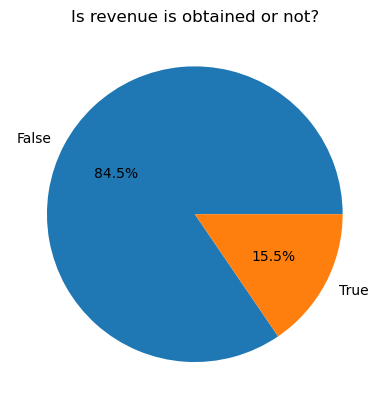

In [19]:
classes_count=data["Revenue"].value_counts()
plt.pie(classes_count,labels=classes_count.index,autopct="%1.1f%%")
plt.title("Is revenue is obtained or not?")
plt.show()

In [33]:
x=data.drop(columns=['Revenue'])
y=data['Revenue'].astype(int)
num_features=x.select_dtypes(include=["number"]).columns
cat_features=x.select_dtypes(include=["object","category"]).columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Month']=le.fit_transform(data['Month'])
data['VisitorType']=le.fit_transform(data['VisitorType'])

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

#decision tree model-no pruning
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(
    # max_depth=6,              # prevents deep overfitting
    # min_samples_leaf=30,      # smooths decision boundaries
    # class_weight="balanced",  # handles imbalance
    # random_state=42
)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
# print("Accuracy:",accuracy_score(y_test,y_pred))

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.5357607282184655

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      2084
           1       0.53      0.54      0.54       382

    accuracy                           0.86      2466
   macro avg       0.72      0.73      0.73      2466
weighted avg       0.86      0.86      0.86      2466


Confusion Matrix:
 [[1903  181]
 [ 176  206]]
